# Solve Linear Transport equation with periodic boundary conditions


In [1]:
import torch 
from torch import nn
import math 
import numpy as np 
import matplotlib.pyplot as plt 

from utils.ELM_structure import *
from utils.data import * 
from Linear_Transport_utils import * 
from mpl_toolkits.axes_grid1 import make_axes_locatable # allows you to easily add new axes next to an existing plot 
import warnings
# warnings.filterwarnings('ignore') 
import time 

In [2]:
# MPS or CUDA or CPU 
if torch.backends.mps.is_available(): 
    device = torch.device('mps') 
elif torch.cuda.is_available(): 
    device = torch.device('cuda') 
else: 
    devcie = torch.device('cpu') 

print(f"Wroking on {device}") 

Wroking on mps


# Building the  Extreme Learning Machine: 
\begin{equation}
u(x) = \sum_{k=1}^{N} \beta_{k} \sigma(<\omega_{k}, x> + b_{k}) 
\end{equation} 

Only train the coefficients $\beta_{k}$

In [6]:
# the physics-informed neural network 
class ELM_Linear_Transport():   
    # For periodic boundary conditions 
    def __init__(self, X, X_init, u_init, t_bc, D, lb, ub, wave_speed): 
        # boundary conditions: domain bounds 
        self.lb = torch.tensor(lb).float().to(device) 
        self.ub = torch.tensor(ub).float().to(device) 

        # Training points  
        self.x = torch.tensor(X[:, 0:1], requires_grad = True).float().to(device) # spatial points 
        self.t = torch.tensor(X[:, 1:2], requires_grad = True).float().to(device) # temporal points 

        # Initial data 
        self.x_init = torch.tensor(X_init[:]).float().to(device) # initial data points 
        self.t_init = torch.zeros_like(self.x_init).float().to(device) # t = 0 
        self.u_init = torch.tensor(u_init).float().to(device)

        # Boundary data points for periodic boundary conditions 
        self.t_bc = torch.tensor(t_bc).float().to(device) 
        # For periodic boundary condition
        self.x_left = self.lb[0] * torch.ones_like(self.t_bc) 
        self.x_right = self.ub[0] * torch.ones_like(self.t_bc) 
               
        # Wave speed  
        self.wave_speed = wave_speed

        # Regularization parameter
        self.lambda1 = 1.0 
        self.lambda2 = 1.0 
        self.lambda3 = 1.0 

        # one-layer neural network 
        self.elm = ELM(2, D).to(device) 

        # optimizers: using the same settings 
        self.optimizer = torch.optim.LBFGS( # requires multiple evaluation of the loss function per iteration 
            self.elm.parameters(),    # target to be optimized 
            lr = 1.0,    # learning rate: step length 
            max_iter = 1,    # maximum number of iterations 
            max_eval = 50000,    # total number of times the closure (loss + backward pass) can be called 
            history_size = 50, 
            tolerance_grad = 1e-7, 
            tolerance_change = 1e-8,
            line_search_fn = "strong_wolfe"      # "strong wolfe condition
        ) 
        
        self.optimizer_Adam = torch.optim.Adam(self.elm.parameters(), lr = 1e-3, betas = (0.9, 0.999))
        self.iter = 0 

    def net_u(self, x, t): # predicted value 
        u = self.elm(torch.cat([x, t], dim = 1)) 
        return u 

    def net_f(self, x ,t): 
        """ The pytorch autograd version of calculating residual """ 
        u = self.net_u(x,t) 

        u_t = torch.autograd.grad(
            u, t, 
            grad_outputs = torch.ones_like(u), 
            retain_graph = True, 
            create_graph = True
        )[0]

        u_x = torch.autograd.grad( 
            u, x, 
            grad_outputs = torch.ones_like(u), 
            retain_graph = True, 
            create_graph = True
        )[0] 

        f = u_t + self.wave_speed * u_x 
        return f 

    # Initial data loss 
    def Init_loss_func(self):
        u0 = self.net_u(self.x_init, self.t_init)
        Init_loss = torch.mean(torch.pow(self.u_init - u0, 2)) * self.lambda1
        return Init_loss 
        
    # Boundary data loss     
    def bc_loss_func(self, x_left, x_right, t): 
        u_left = self.net_u(x_left, t) 
        u_right = self.net_u(x_right, t) 
        bc_loss = torch.mean(torch.pow(u_left - u_right ,2)) * self.lambda2 
        return bc_loss 
        
    def loss_func(self): 
        f_pred = self.net_f(self.x, self.t)  
        loss = torch.mean(f_pred ** 2) * self.lambda3 + self.bc_loss_func(self.x_left, self.x_right, self.t_bc) + self.Init_loss_func() 
        return loss 
        
    def closure(self): 
        loss_value = self.loss_func() 
        self.optimizer.zero_grad()                             # reset gradients
        loss_value.backward()                                  # compute gradients but only the network weights will be updated 
        return loss_value  

    def train(self, nIter1, nIter2 = 2000):
        self.elm.train()
        # Backward and optimize: 2nd phase optimization 
        # Two Phase optimization 
        for epoch in range(nIter1):
            # PDE loss 
            f_pred = self.net_f(self.x, self.t)

            # data loss: Boundary condition mismatch 
            bc_loss = self.bc_loss_func(self.x_left, self.x_right, self.t_bc) 
            
            # data loss: Initial condition mismatch 
            ic_loss = self.Init_loss_func() 
            
            # total loss: IC+ BC + PDE 
            loss =  torch.mean(torch.pow(f_pred, 2)) + bc_loss + ic_loss 

            # Backward and optimize 
            self.optimizer_Adam.zero_grad()
            loss.backward()
            self.optimizer_Adam.step()
            
            if epoch % 100 == 0: 
                print(
                    'It: %d, Loss: %.3e' % 
                    ( 
                        epoch, 
                        loss.item()
                    )
                )
        # Second Phase Optimization         
        for i in range(nIter2):  # 5000 iterations
            loss_value = self.optimizer.step(self.closure) # Never pass tensors into optimizer.step
            self.iter += 1
            if self.iter % 100 == 0:
                print('It: %d, Loss: %e' % (self.iter, loss_value.item()))
        
    # def predict(self, X, X_bc, T_bc):
    def predict(self, X):
        x = torch.as_tensor(X[:, 0:1], dtype = torch.float32, device = device) 
        x.requires_grad_(True) 
        t = torch.as_tensor(X[:, 1:2], dtype = torch.float32, device = device) 
        t.requires_grad_(True)         
        self.elm.eval()
        with torch.no_grad():
            u = self.net_u(x, t)  
        f = self.net_f(x, t)     
        u = u.detach().cpu().numpy()
        f = f.detach().cpu().numpy() 
        return u, f     

# Configurations

In [7]:
# Domain bounds 
lb = np.array([-1.0, 0.0]) 
ub = np.array([1.0, 1.0]) 
wave_speed = 12 

# Grid point setup 
N_bc = 100
Nx_int = 50 
Nt_int = 100 
N_init = 100 

 

# Interior part 
X_train_int = interior_points(Nx_int, Nt_int, lb[0], ub[0], lb[1], ub[1])  
print(f"X_train_int shape: {np.shape(X_train_int)}")

# Initial part 
X_train_init = init_points(N_init, lb[0], ub[0]) 
U_train_init = u_0(X_train_init)
print('X_train_init shape: ', np.shape(X_train_init)) 
print('U_train_init shape: ', np.shape(U_train_init)) 

T_bc = bc_points(N_bc, lb[1], ub[1])
print('T_bc shape: ', np.shape(T_bc)) 

X_train_int shape: (5000, 2)
X_train_init shape:  (100, 1)
U_train_init shape:  (100, 1)
T_bc shape:  (100, 1)


# Generate Test data and solution  

In [8]:
# Generate test data 
Nx = 200 
Nt = 50
X_test, u_test = test_data(Nx, Nt, lb[0], ub[0], lb[1], ub[1], wave_speed)
print(f"X_test shape: {X_test.shape}") 
print(f"u_test shape: {u_test.shape}") 

X_test shape: (10000, 2)
u_test shape: (10000, 1)


# Training on non-noisy data 

In [9]:
noise = 0.0 
D = 3600 
model = ELM_Linear_Transport(X_train_int, X_train_init, U_train_init, T_bc, D, lb, ub, wave_speed) 
# training
start = time.time()
model.train(2500, 1500)
end = time.time()

It: 0, Loss: 1.105e+00
It: 100, Loss: 5.271e-01
It: 200, Loss: 5.032e-01
It: 300, Loss: 4.935e-01
It: 400, Loss: 4.867e-01
It: 500, Loss: 4.804e-01
It: 600, Loss: 4.744e-01
It: 700, Loss: 4.688e-01
It: 800, Loss: 4.636e-01
It: 900, Loss: 4.588e-01
It: 1000, Loss: 4.545e-01
It: 1100, Loss: 4.505e-01
It: 1200, Loss: 4.470e-01
It: 1300, Loss: 4.440e-01
It: 1400, Loss: 4.413e-01
It: 1500, Loss: 4.389e-01
It: 1600, Loss: 4.368e-01
It: 1700, Loss: 4.349e-01
It: 1800, Loss: 4.333e-01
It: 1900, Loss: 4.318e-01
It: 2000, Loss: 1.034e+00
It: 2100, Loss: 4.295e-01
It: 2200, Loss: 4.284e-01
It: 2300, Loss: 4.274e-01
It: 2400, Loss: 4.732e-01
It: 100, Loss: 3.928068e-01
It: 200, Loss: 3.816848e-01
It: 300, Loss: 3.736991e-01
It: 400, Loss: 3.592174e-01
It: 500, Loss: 3.533006e-01
It: 600, Loss: 3.500281e-01
It: 700, Loss: 3.426998e-01
It: 800, Loss: 3.411306e-01
It: 900, Loss: 3.395968e-01
It: 1000, Loss: 3.374496e-01
It: 1100, Loss: 3.369546e-01
It: 1200, Loss: 3.362775e-01
It: 1300, Loss: 3.35588

In [10]:
# evaluations 
u_pred, f_pred = model.predict(X_test) 
print(f"u_pred shape: {np.shape(u_pred)}") 
print(f"f_pred shape: {np.shape(f_pred)}") 

error_u = np.linalg.norm(u_test - u_pred, 2) / np.linalg.norm(u_test, 2) # relative L^{2} square norm 
error_f = np.linalg.norm(f_pred, ord = np.inf) 

print('Error u: %e' % (error_u)) 
print('PDE loss: %e' % (error_f)) 
print(f'Training time is {end-start:.2f} seconds')

u_pred shape: (10000, 1)
f_pred shape: (10000, 1)
Error u: 1.069819e+00
PDE loss: 1.078639e+00
Training time is 132.04 seconds


In [11]:
noise = 0.0 
err_l2 = np.zeros([10]) 
err_linf = np.zeros([10]) 
Training_time = np.zeros([10]) 
wave_speed = 12 
D = 3600 

# Training points 
training_sets = np.load(
    "Linear_Transport_training_points_5000_sets.npy",
    allow_pickle=True
)

for k in range(10): 
    data = training_sets[k] 
    X_train_int = data["X_train_int"] 
    X_train_init = data["X_train_init"] 
    U_train_init = u_0(X_train_init)
    T_bc = data["T_bc"]
    model = ELM_Linear_Transport(X_train_int, X_train_init, U_train_init, T_bc, D, lb, ub, wave_speed) 
    start = time.time() 
    model.train(2500, 1500) 
    end = time.time() 
    u_pred, f_pred = model.predict(X_test) 
    err_l2[k] = np.linalg.norm(abs(u_test - u_pred), 2) / np.linalg.norm(u_test, 2) 
    err_linf[k] = np.max(np.abs(u_test - u_pred))
    Training_time[k] = (end - start) 

NameError: name 'ELM_Linear_Advection' is not defined

In [26]:
print("err_l2 mean: ", np.mean(err_l2))
print("err_linf mean: ", np.mean(err_linf)) 
print("err_l2 std: ", np.std(err_l2)) 
print("err_linf std: ", np.std(err_linf))

err_l2 mean:  1.1591239259549264
0.06925604147931433
err_linf mean:  1.5116492915993462
0.08840430335395229
Training time mean:  154.08183755874634
36.2868857655867


In [27]:
# Save the results 
results = {
    "Model": "ELM",
    "num_features": D, 
    "Training_points_int_bc": [Nx, Nt, N_bc], 
    "L2_error": err_l2,
    "Linf_error": err_linf,  
    "Training_time": Training_time,
}

# torch.save(results, "Linear_Transport_ELM_5000_training_points_data.pt")

# Visualization 

' \nfig.subplots_adjust(\n    wspace=0.08,\n    bottom=0.25\n)\n'

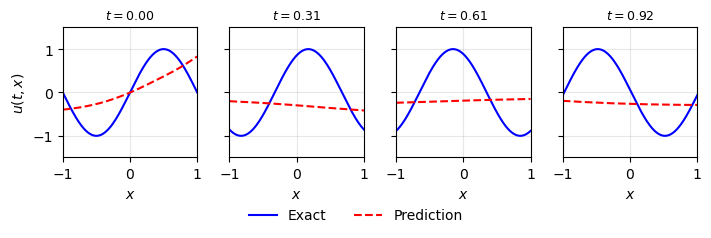

In [12]:
import matplotlib.gridspec as gridspec 

fig, axes = plt.subplots(
    1, 4,
    figsize=(7, 2),
    sharey=True,
    constrained_layout=True,
    gridspec_kw={'wspace': 0.1}
)
# fig.subplots_adjust(wspace=0.1)

times = [0, 15, 30, 45]

for ax, idx in zip(axes, times):
    ax.plot(
        X_test[idx*Nx:(idx+1)*Nx, 0:1],
        u_test[idx*Nx:(idx+1)*Nx],
        'b-',
        linewidth=1.5,
        label='Exact'
    )
    ax.plot(
        X_test[idx*Nx:(idx+1)*Nx, 0:1],
        u_pred[idx*Nx:(idx+1)*Nx,0],
        'r--',
        linewidth=1.5,
        label='Prediction'
    )

    ax.set_title(
        rf'$t={X_test[idx * Nx, 1]:.2f}$',
        fontsize=9
    )

    ax.set_xlim([-1,1])
    ax.set_ylim([-1.5,1.5])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r'$u(t,x)$')
for ax in axes:
    ax.set_xlabel(r'$x$')
""" 
axes[1].legend(
    loc='lower center',
    bbox_to_anchor=(0.5,-0.75),
    ncol=2,
    frameon=False
)
"""
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.15)
)
""" 
fig.subplots_adjust(
    wspace=0.08,
    bottom=0.25
)
""" 
# fig.savefig("Linear_Transport_ELM.png", dpi=300, bbox_inches='tight')
